In [21]:
!pip install numpy matplotlib seaborn

In [22]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [23]:
#Data ingestion
df = pd.read_csv('./dataset/house_price.csv')
df.head()

,Amount(in rupees),Carpet Area,Furnishing,Bathroom,Balcony,Car Parking,New Property,Rent/Lease,Resale,Ownership_Freehold,...,trivandrum,udaipur,udupi,vadodara,vapi,varanasi,vijayawada,visakhapatnam,vrindavan,zirakpur
0,4200000.0,500.0,0,1.0,2.0,1.0,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
1,9800000.0,473.0,1,2.0,2.0,1.0,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
2,14000000.0,779.0,0,2.0,2.0,1.0,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
3,16000000.0,635.0,0,2.0,2.0,1.0,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,4500000.0,1050.0,0,1.0,1.0,1.0,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [24]:
# Check number of rows and columns

print("Dataset Shape :", df.shape)

# Display column names

print(df.columns)

# Display data types

df.info()

# Basic statistical summary

df.describe()

Dataset Shape : (60312, 105)
Index(['Amount(in rupees)', 'Carpet Area', 'Furnishing', 'Bathroom', 'Balcony',
       'Car Parking', 'New Property', 'Rent/Lease', 'Resale',
       'Ownership_Freehold',
       ...
       'trivandrum', 'udaipur', 'udupi', 'vadodara', 'vapi', 'varanasi',
       'vijayawada', 'visakhapatnam', 'vrindavan', 'zirakpur'],
      dtype='str', length=105)
<class 'pandas.DataFrame'>
RangeIndex: 60312 entries, 0 to 60311
Columns: 105 entries, Amount(in rupees) to zirakpur
dtypes: bool(97), float64(7), int64(1)
memory usage: 9.3 MB


,Amount(in rupees),Carpet Area,Furnishing,Bathroom,Balcony,Car Parking,Floor No,Total Floors
count,6.031200e+04,60312.000000,60312.000000,60312.000000,60312.000000,60312.000000,56703.000000,60273.000000
mean,1.087289e+07,1171.121220,0.712677,2.425255,2.070997,1.106712,4.571963,8.568795
std,6.537241e+07,3948.284719,0.685515,0.876963,0.863213,0.481200,4.471900,6.963693
min,1.000000e+05,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,4.200000e+06,1000.000000,0.000000,2.000000,2.000000,1.000000,2.000000,4.000000
50%,6.500000e+06,1050.000000,1.000000,2.000000,2.000000,1.000000,3.000000,5.000000
75%,1.100000e+07,1110.000000,1.000000,3.000000,2.000000,1.000000,6.000000,12.000000
max,1.400300e+10,709222.000000,2.000000,10.000000,10.000000,10.000000,200.000000,200.000000


In [25]:
# Check missing values

print(df.isnull().sum())

# Remove rows containing missing values

df = df.dropna()

# Remove duplicate records

df = df.drop_duplicates()

# Verify dataset after cleaning

print("New Shape :", df.shape)

Amount(in rupees)    0
Carpet Area          0
Furnishing           0
Bathroom             0
Balcony              0
                    ..
varanasi             0
vijayawada           0
visakhapatnam        0
vrindavan            0
zirakpur             0
Length: 105, dtype: int64
New Shape : (56669, 105)


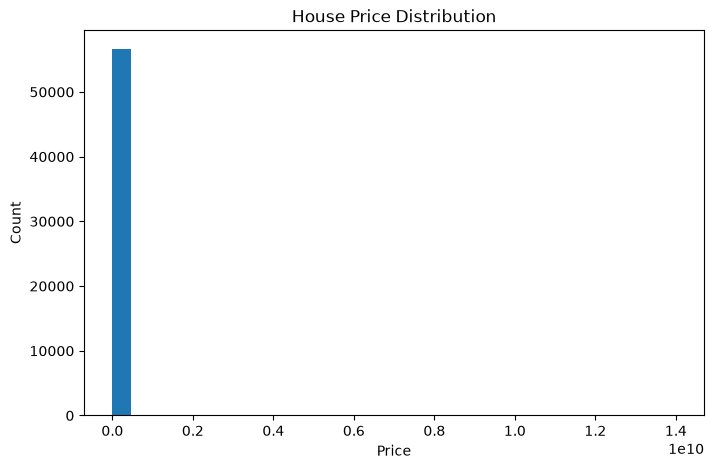

In [26]:
# Plot distribution of house prices

plt.figure(figsize=(8,5))
plt.hist(df["Amount(in rupees)"], bins=30)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

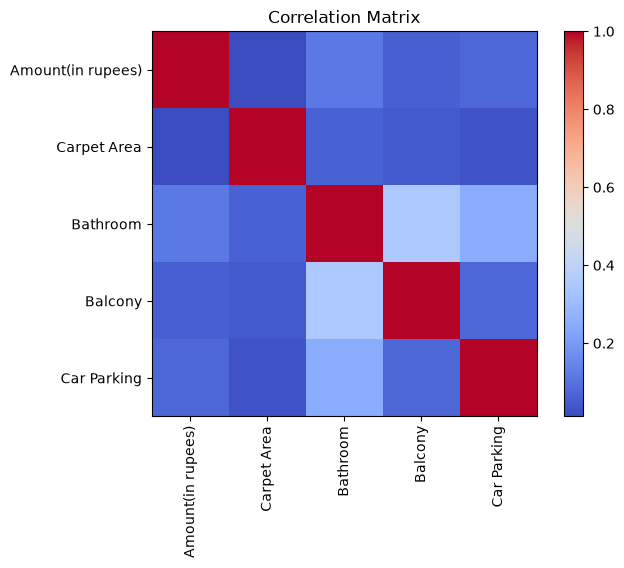

In [27]:
# Correlation among numerical columns

corr = df[[
    "Amount(in rupees)",
    "Carpet Area",
    "Bathroom",
    "Balcony",
    "Car Parking"
]].corr()

plt.figure(figsize=(7,5))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

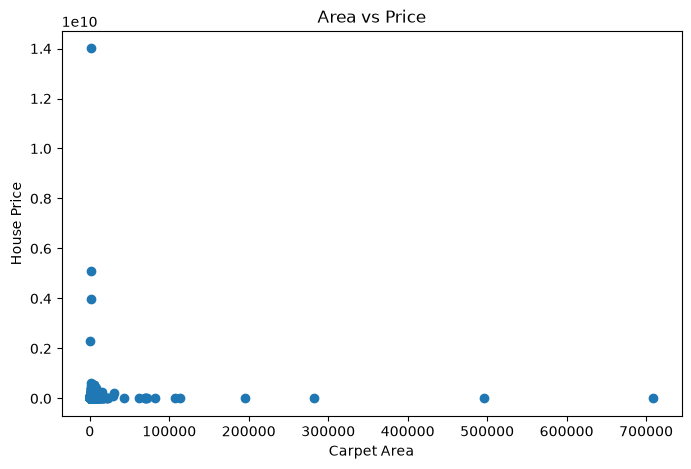

In [28]:
# Relationship between carpet area and price

plt.figure(figsize=(8,5))

plt.scatter(
    df["Carpet Area"],
    df["Amount(in rupees)"]
)

plt.xlabel("Carpet Area")
plt.ylabel("House Price")

plt.title("Area vs Price")

plt.show()

In [29]:
# Separate input and output

X = df.drop("Amount(in rupees)", axis=1)

y = df["Amount(in rupees)"]

In [30]:
# Split data into training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


In [31]:
# Scale input features

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
# Create ANN model

model = Sequential()

# Input layer

model.add(Dense(64,
                activation="relu",
                input_shape=(X_train.shape[1],)))

# Hidden layer

model.add(Dense(32,
                activation="relu"))

# Hidden layer

model.add(Dense(16,
                activation="relu"))

# Output layer

model.add(Dense(1,
                activation="linear"))

c:\Users\Soham Deshmukh\Desktop\B.Tech\ADS\ADS-PEIT412B\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
# Configure the ANN

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [34]:
# Train the model

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.20
)

Epoch 1/50
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 6452463049637888.0000 - mae: 10790509.0000 - val_loss: 364411566948352.0000 - val_mae: 9718944.0000
Epoch 2/50
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6369022035623936.0000 - mae: 8262709.5000 - val_loss: 240728655527936.0000 - val_mae: 6107662.5000
Epoch 3/50
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6273766640320512.0000 - mae: 5924181.5000 - val_loss: 194388122664960.0000 - val_mae: 5619586.5000
Epoch 4/50
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6255591949336576.0000 - mae: 5829175.5000 - val_loss: 187048610758656.0000 - val_mae: 5604494.0000
Epoch 5/50
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 6250046609686528.0000 - mae: 5794651.5000 - val_loss: 183342641184768.0000 - val_mae: 5508388.5000
Epoch 6/50
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6246209056407552.0000 - mae: 5672162.0000 - val_loss: 180134820708352.0000 - val_mae: 5411129.0000
Epoch 7/50
1134/1134 ━━━━━━━━━━━━

In [35]:
# Evaluate on testing data

loss, mae = model.evaluate(
    X_test,
    y_test
)

print("Test Loss :", loss)
print("Test MAE :", mae)

355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1966689818247168.0000 - mae: 5296472.0000
Test Loss : 1966689818247168.0
Test MAE : 5296472.0


In [36]:
# Predict house prices

predictions = model.predict(X_test)

predictions = predictions.flatten()

355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [37]:
# Calculate evaluation metrics

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("Mean Absolute Error :", mae)
print("Root Mean Square Error :", rmse)
print("R2 Score :", r2)

Mean Absolute Error : 5296472.792844504
Root Mean Square Error : 44347372.55109518
R2 Score : 0.04493394899275871


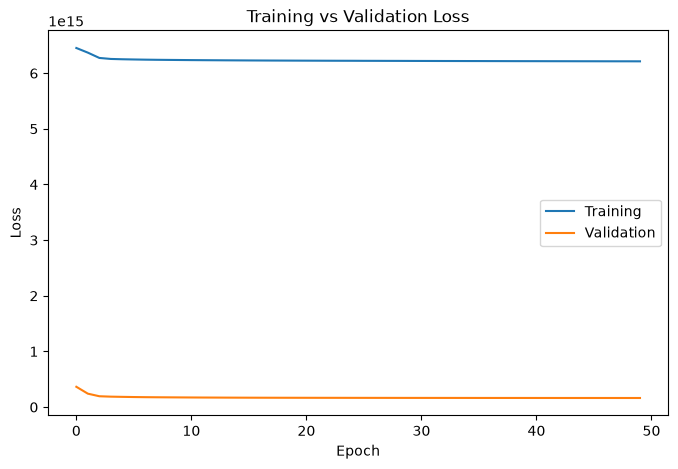

In [38]:
# Plot training loss

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend(["Training","Validation"])

plt.show()

In [39]:
# Compare first 10 predictions

result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predictions
})

result.head(10)

,Actual Price,Predicted Price
0,8000000.0,1.093805e+06
1,7500000.0,1.532892e+07
2,3500000.0,8.950083e+06
3,4000000.0,4.135439e+06
4,49000000.0,3.979131e+07
5,2700000.0,4.835439e+05
6,6500000.0,7.042888e+06
7,2750000.0,6.330600e+06
8,12500000.0,1.378866e+07
9,3500000.0,1.931263e+04


The dataset was successfully loaded and cleaned.

Basic exploratory data analysis was performed to understand the data.

The features were scaled before training the neural network.

An Artificial Neural Network with three hidden layers was developed using TensorFlow/Keras.

The model was trained using the Adam optimizer and Mean Squared Error loss function.

Finally, the model was evaluated using MAE, RMSE and R² Score for house price prediction.